## Figure to demonstrate the equal distribution of biomass across size classes.

In [443]:
# objective: generate the particle size structure for the CMIP6 models
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
import xarray as xr
import pandas as pd
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import glob,os,subprocess
from glob import glob
import IPython.display as display
from datetime import datetime as dt
%matplotlib inline
from scipy.stats import linregress
import math

## CESM

In [444]:
ds_hist = xr.open_mfdataset('/Users/mc4214/CMIP6_biome_PSS_data/biom_CESM_PSS_hist_biovolume.nc')

In [445]:
# dictionary with total biovolume
total_biovol_m3={}
total_biovol_m3['globalSum_m3']={}
total_biovol_m3['globalSum_m3']['phypico'] = ds_hist.phypico.mean(dim='time').sum(dim=['lon','lat']).values
total_biovol_m3['globalSum_m3']['phydiat'] = ds_hist.phydiat.mean(dim='time').sum(dim=['lon','lat']).values
total_biovol_m3['globalSum_m3']['zooc'] = ds_hist.zooc.mean(dim='time').sum(dim=['lon','lat']).values
# transform the dictionary to a dataframe
total_biovol_m3=pd.DataFrame.from_dict(total_biovol_m3)
total_biovol_m3=total_biovol_m3.reset_index()
total_biovol_m3.columns.values[0]='name'
total_biovol_m3

,name,globalSum_m3
0,phydiat,4.318585524442167e+19
1,phypico,4.984054867883452e+18
2,zooc,2.3337619909393393e+18


In [446]:
sizes=np.linspace(np.log10(0.5),np.log10(2.*1000.),num=50,endpoint=False)
#10**(sizes)
#sizes

In [447]:
dd=np.diff(sizes)[0]
sizes_min=10**(sizes-dd/2)
sizes_max=10**(sizes+dd/2)
size_range=[str(np.round(10**s,3))+': '+'['+str(np.round(x,3))+','+str(np.round(y,3))+')' for s,x,y in zip(sizes,sizes_min,sizes_max)]
#size_range

In [448]:
sizedf=pd.DataFrame([10**sizes]).transpose()
sizedf.columns=['sizes']
sizedf['phyto']= None
sizedf['zoo']= None
#sizedf.loc[sizedf.sizes < 10,'phyto']='smp'
sizedf.loc[(sizedf.sizes > 0.5) & (sizedf.sizes < 10),'phyto']='phypico'
sizedf.loc[(sizedf.sizes > 10) & (sizedf.sizes < 100),'phyto']='phydiat' ##Playing with diatom size 
sizedf.loc[(sizedf.sizes > 10) & (sizedf.sizes < 2000),'zoo']='zooc'
#sizedf.loc[(sizedf.sizes > 2000) & (sizedf.sizes < 20000),'zoo']='lgz'
##this step is necessary to remove the empty categories when we are not considering phymisc



sizedf = sizedf.reset_index(drop=True)


In [449]:
# determine the degree of overlap between size bins. In COBALT (and perhaps other models) the degree of overlap might need to be determined following 
# Jessica's method

# the goal is to have repeated entries for a size class if it occurs across plantkon types:
sdfm_CESM = pd.melt(sizedf, id_vars='sizes',var_name='type',value_name='name')
sdfm_CESM = sdfm_CESM.dropna().reset_index(drop=True)
pd.set_option('display.max_rows',80)
sdfm_CESM['biovolume_um3']=(4/3)*math.pi*(sdfm_CESM.sizes/2)**3

In [450]:

sdfm_CESM['globalSum_m3_split']=0
for s in sdfm_CESM.name.unique():
    n=len(sdfm_CESM.loc[sdfm_CESM.name==s].index)
    print(s, n)
    sdfm_CESM.loc[sdfm_CESM.name==s,'globalSum_m3_split'] = np.tile(total_biovol_m3.loc[total_biovol_m3.name==s,'globalSum_m3']/n,n)
#sdfm_CESM

phypico 18
phydiat 13
zooc 31


In [451]:
sdfm_CESM = sdfm_CESM.sort_values(by='biovolume_um3', ascending=True)

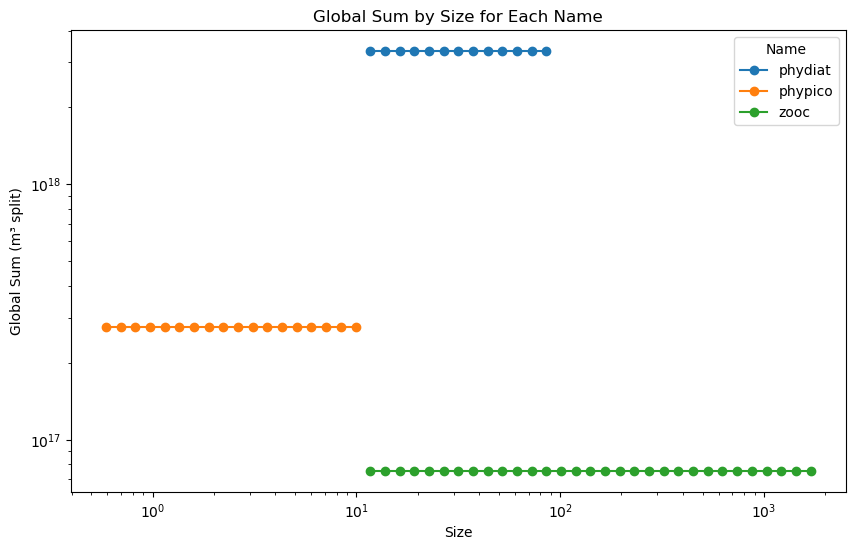

In [452]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming sdfm is your dataframe

plt.figure(figsize=(10, 6))

# Plot each group (by 'name') with lines and dots
# Add legend
for name, group in sdfm_CESM.groupby('name'):
    plt.plot(group['sizes'], group['globalSum_m3_split'], marker='o', linestyle='-', label=name)

# Set log scale (common for size spectra)
plt.xscale('log')
plt.yscale('log')

# Labels and title
plt.xlabel('Size')
plt.ylabel('Global Sum (m³ split)')
plt.title('Global Sum by Size for Each Name')

# Add legend
plt.legend(title="Name")

plt.show()



## CMCC

In [453]:
ds_hist = xr.open_mfdataset('/Users/mc4214/CMIP6_biome_PSS_data/biom_CMCC_PSS_hist_biovolume.nc')

In [454]:
# dictionary with total biovolume
total_biovol_m3={}
total_biovol_m3['globalSum_m3']={}
total_biovol_m3['globalSum_m3']['phydiat'] = ds_hist.phydiat.mean(dim='time').sum(dim=['lon','lat']).values
total_biovol_m3['globalSum_m3']['phymisc'] = ds_hist.phymisc.mean(dim='time').sum(dim=['lon','lat']).values
total_biovol_m3['globalSum_m3']['zmicro'] = ds_hist.zmicro.mean(dim='time').sum(dim=['lon','lat']).values
total_biovol_m3['globalSum_m3']['zmeso'] = ds_hist.zmicro.mean(dim='time').sum(dim=['lon','lat']).values
# transform the dictionary to a dataframe
total_biovol_m3=pd.DataFrame.from_dict(total_biovol_m3)
total_biovol_m3=total_biovol_m3.reset_index()
total_biovol_m3.columns.values[0]='name'
total_biovol_m3

,name,globalSum_m3
0,phydiat,1.4585105704096383e+19
1,phymisc,2.913222375674877e+18
2,zmeso,3.5872560772953754e+17
3,zmicro,3.5872560772953754e+17


In [455]:
sizes=np.linspace(np.log10(2),np.log10(35.*1000.),num=50,endpoint=False)
#10**(sizes)
#sizes

In [456]:
dd=np.diff(sizes)[0]
sizes_min=10**(sizes-dd/2)
sizes_max=10**(sizes+dd/2)
size_range=[str(np.round(10**s,3))+': '+'['+str(np.round(x,3))+','+str(np.round(y,3))+')' for s,x,y in zip(sizes,sizes_min,sizes_max)]
#size_range

In [457]:
sizedf=pd.DataFrame([10**sizes]).transpose()
sizedf.columns=['sizes']
sizedf['phyto']= None
sizedf['zoo']= None
#sizedf.loc[sizedf.sizes < 10,'phyto']='smp'
sizedf.loc[(sizedf.sizes > 2) & (sizedf.sizes < 20),'phyto']='phymisc'
sizedf.loc[(sizedf.sizes > 20) & (sizedf.sizes < 200),'phyto']='phydiat' ##Playing with diatom size 
sizedf.loc[(sizedf.sizes > 20) & (sizedf.sizes < 200),'zoo']='zmicro'
sizedf.loc[(sizedf.sizes > 200) & (sizedf.sizes < 35000),'zoo']='zmeso'
#sizedf.loc[(sizedf.sizes > 2000) & (sizedf.sizes < 20000),'zoo']='lgz'
##this step is necessary to remove the empty categories when we are not considering phymisc



sizedf = sizedf.reset_index(drop=True)

#sizedf


In [458]:
# determine the degree of overlap between size bins. In COBALT (and perhaps other models) the degree of overlap might need to be determined following 
# Jessica's method

# the goal is to have repeated entries for a size class if it occurs across plantkon types:
sdfm_CMCC = pd.melt(sizedf, id_vars='sizes',var_name='type',value_name='name')
sdfm_CMCC  = sdfm_CMCC .dropna().reset_index(drop=True)
pd.set_option('display.max_rows',80)
sdfm_CMCC ['biovolume_um3']=(4/3)*math.pi*(sdfm_CMCC.sizes/2)**3

In [459]:

sdfm_CMCC ['globalSum_m3_split']=0
for s in sdfm_CMCC.name.unique():
    n=len(sdfm_CMCC.loc[sdfm_CMCC.name==s].index)
    print(s, n)
    sdfm_CMCC.loc[sdfm_CMCC.name==s,'globalSum_m3_split'] = np.tile(total_biovol_m3.loc[total_biovol_m3.name==s,'globalSum_m3']/n,n)
#sdfm_CESM

phymisc 11
phydiat 12
zmicro 12
zmeso 26


In [460]:
sdfm_CMCC= sdfm_CMCC.sort_values(by='biovolume_um3', ascending=True)

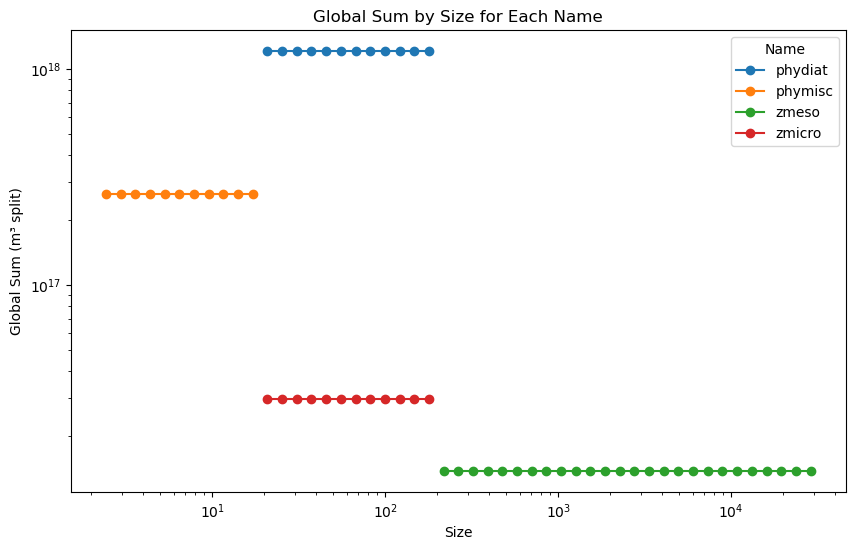

In [461]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming sdfm is your dataframe

plt.figure(figsize=(10, 6))

# Plot each group (by 'name') with lines and dots
# Add legend
for name, group in sdfm_CMCC.groupby('name'):
    plt.plot(group['sizes'], group['globalSum_m3_split'], marker='o', linestyle='-', label=name)

# Set log scale (common for size spectra)
plt.xscale('log')
plt.yscale('log')

# Labels and title
plt.xlabel('Size')
plt.ylabel('Global Sum (m³ split)')
plt.title('Global Sum by Size for Each Name')

# Add legend
plt.legend(title="Name")

plt.show()



## CNRM

In [462]:
ds_hist = xr.open_mfdataset('/Users/mc4214/CMIP6_biome_PSS_data/biom_CNRM_PSS_hist_biovolume.nc')

In [463]:
# dictionary with total biovolume
total_biovol_m3={}
total_biovol_m3['globalSum_m3']={}
total_biovol_m3['globalSum_m3']['phydiat'] = ds_hist.phydiat.mean(dim='time').sum(dim=['lon','lat']).values
total_biovol_m3['globalSum_m3']['phymisc'] = ds_hist.phymisc.mean(dim='time').sum(dim=['lon','lat']).values
total_biovol_m3['globalSum_m3']['zmicro'] = ds_hist.zmicro.mean(dim='time').sum(dim=['lon','lat']).values
total_biovol_m3['globalSum_m3']['zmeso'] = ds_hist.zmicro.mean(dim='time').sum(dim=['lon','lat']).values
# transform the dictionary to a dataframe
total_biovol_m3=pd.DataFrame.from_dict(total_biovol_m3)
total_biovol_m3=total_biovol_m3.reset_index()
total_biovol_m3.columns.values[0]='name'
total_biovol_m3

,name,globalSum_m3
0,phydiat,7.711533230792927e+20
1,phymisc,2.053148056737785e+19
2,zmeso,5.219473061703006e+17
3,zmicro,5.219473061703006e+17


In [464]:
sizes=np.linspace(np.log10(1),np.log10(2.*1000.),num=50,endpoint=False)
#10**(sizes)
#sizes

In [465]:
dd=np.diff(sizes)[0]
sizes_min=10**(sizes-dd/2)
sizes_max=10**(sizes+dd/2)
size_range=[str(np.round(10**s,3))+': '+'['+str(np.round(x,3))+','+str(np.round(y,3))+')' for s,x,y in zip(sizes,sizes_min,sizes_max)]
#size_range

In [466]:
sizedf=pd.DataFrame([10**sizes]).transpose()
sizedf.columns=['sizes']
sizedf['phyto']= None
sizedf['zoo']= None
#sizedf.loc[sizedf.sizes < 10,'phyto']='smp'
sizedf.loc[(sizedf.sizes >1) & (sizedf.sizes < 10),'phyto']='phymisc'
sizedf.loc[(sizedf.sizes > 10) & (sizedf.sizes < 40),'phyto']='phydiat' ##Playing with diatom size 
sizedf.loc[(sizedf.sizes > 10) & (sizedf.sizes < 200),'zoo']='zmicro'
sizedf.loc[(sizedf.sizes > 200) & (sizedf.sizes < 2000),'zoo']='zmeso'
#sizedf.loc[(sizedf.sizes > 2000) & (sizedf.sizes < 20000),'zoo']='lgz'
##this step is necessary to remove the empty categories when we are not considering phymisc



sizedf = sizedf.reset_index(drop=True)

#sizedf

In [467]:
# determine the degree of overlap between size bins. In COBALT (and perhaps other models) the degree of overlap might need to be determined following 
# Jessica's method

# the goal is to have repeated entries for a size class if it occurs across plantkon types:
sdfm_CNRM = pd.melt(sizedf, id_vars='sizes',var_name='type',value_name='name')
sdfm_CNRM  = sdfm_CNRM .dropna().reset_index(drop=True)
pd.set_option('display.max_rows',80)
sdfm_CNRM ['biovolume_um3']=(4/3)*math.pi*(sdfm_CNRM.sizes/2)**3

In [468]:

sdfm_CNRM ['globalSum_m3_split']=0
for s in sdfm_CNRM.name.unique():
    n=len(sdfm_CNRM.loc[sdfm_CNRM.name==s].index)
    print(s, n)
    sdfm_CNRM.loc[sdfm_CNRM.name==s,'globalSum_m3_split'] = np.tile(total_biovol_m3.loc[total_biovol_m3.name==s,'globalSum_m3']/n,n)
#sdfm_CESM

phymisc 15
phydiat 9
zmicro 19
zmeso 15


In [469]:
sdfm_CNRM= sdfm_CNRM.sort_values(by='biovolume_um3', ascending=True)

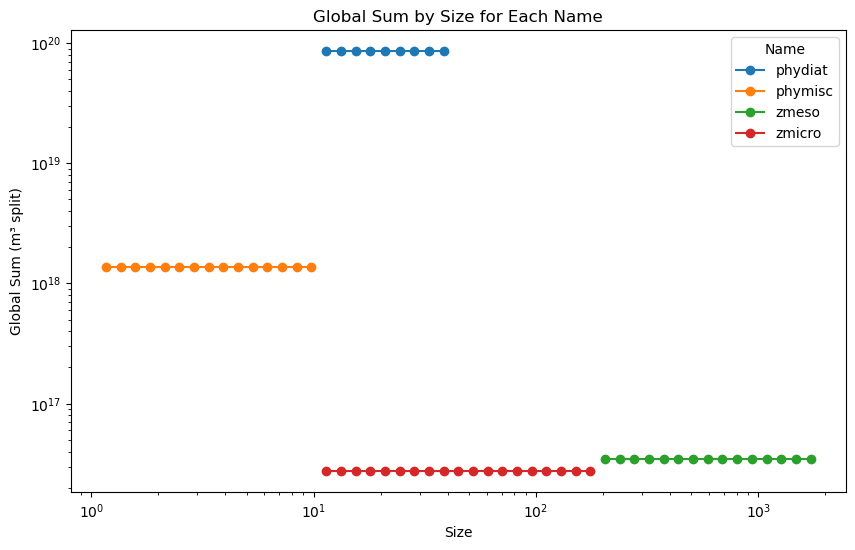

In [470]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming sdfm is your dataframe

plt.figure(figsize=(10, 6))

# Plot each group (by 'name') with lines and dots
# Add legend
for name, group in sdfm_CNRM.groupby('name'):
    plt.plot(group['sizes'], group['globalSum_m3_split'], marker='o', linestyle='-', label=name)

# Set log scale (common for size spectra)
plt.xscale('log')
plt.yscale('log')

# Labels and title
plt.xlabel('Size')
plt.ylabel('Global Sum (m³ split)')
plt.title('Global Sum by Size for Each Name')

# Add legend
plt.legend(title="Name")

plt.show()



## GFDL

In [471]:
ds_hist = xr.open_mfdataset('/Users/mc4214/CMIP6_biome_PSS_data/biom_GFDL_PSS_hist_biovolume.nc')

In [472]:
# dictionary with total biovolume
total_biovol_m3={}
total_biovol_m3['globalSum_m3']={}
total_biovol_m3['globalSum_m3']['phypico'] = ds_hist.phydiat.mean(dim='time').sum(dim=['lon','lat']).values
total_biovol_m3['globalSum_m3']['phydiat'] = ds_hist.phydiat.mean(dim='time').sum(dim=['lon','lat']).values
total_biovol_m3['globalSum_m3']['phymisc'] = ds_hist.phymisc.mean(dim='time').sum(dim=['lon','lat']).values
total_biovol_m3['globalSum_m3']['zmicro'] = ds_hist.zmicro.mean(dim='time').sum(dim=['lon','lat']).values
total_biovol_m3['globalSum_m3']['zmeso'] = ds_hist.zmicro.mean(dim='time').sum(dim=['lon','lat']).values
# transform the dictionary to a dataframe
total_biovol_m3=pd.DataFrame.from_dict(total_biovol_m3)
total_biovol_m3=total_biovol_m3.reset_index()
total_biovol_m3.columns.values[0]='name'
total_biovol_m3

,name,globalSum_m3
0,phydiat,8.3345494e+20
1,phymisc,7.251414e+17
2,phypico,8.3345494e+20
3,zmeso,4.6905666e+18
4,zmicro,4.6905666e+18


In [473]:
sizes=np.linspace(np.log10(0.5),np.log10(20.*1000.),num=50,endpoint=False)
#10**(sizes)
#sizes

In [474]:
dd=np.diff(sizes)[0]
sizes_min=10**(sizes-dd/2)
sizes_max=10**(sizes+dd/2)
size_range=[str(np.round(10**s,3))+': '+'['+str(np.round(x,3))+','+str(np.round(y,3))+')' for s,x,y in zip(sizes,sizes_min,sizes_max)]
#size_range

In [475]:
sizedf=pd.DataFrame([10**sizes]).transpose()
sizedf.columns=['sizes']
sizedf['phyto']= None
sizedf['phytomisc']= None
sizedf['zoo']= None
sizedf.loc[(sizedf.sizes > 0.5) & (sizedf.sizes < 10),'phyto']='phypico'
sizedf.loc[(sizedf.sizes > 10) & (sizedf.sizes < 100),'phyto']='phydiat'
#sizedf.loc[(sizedf.sizes > 10) & (sizedf.sizes < 100),'phyto']='phylarge' # 12/19/2022 change sizes in phydiat and phymisc for them to match the other models (sizedf.sizes > 10) & (sizedf.sizes < 200)
sizedf.loc[(sizedf.sizes > 10) & (sizedf.sizes < 100),'phytomisc']='phymisc'
#sizedf.loc[(sizedf.sizes > 5) & (sizedf.sizes < 22),'phyto']='phydiaz' # reference here, double check this
sizedf.loc[(sizedf.sizes > 10) & (sizedf.sizes < 200),'zoo']='zmicro'
sizedf.loc[(sizedf.sizes > 200) & (sizedf.sizes < 20000),'zoo']='zmeso' #updated 12/12/2022, zmeso is large and medium zoo
len(sizedf)

sizedf = sizedf.reset_index(drop=True)

sizedf

,sizes,phyto,phytomisc,zoo
0,0.500000,None,None,None
1,0.618032,phypico,None,None
2,0.763928,phypico,None,None
3,0.944264,phypico,None,None
4,1.167172,phypico,None,None
5,1.442700,phypico,None,None
6,1.783270,phypico,None,None
7,2.204238,phypico,None,None
8,2.724580,phypico,None,None
9,3.367757,phypico,None,None


In [476]:
# determine the degree of overlap between size bins. In COBALT (and perhaps other models) the degree of overlap might need to be determined following 
# Jessica's method

# the goal is to have repeated entries for a size class if it occurs across plantkon types:
sdfm_GFDL = pd.melt(sizedf, id_vars='sizes',var_name='type',value_name='name')
sdfm_GFDL  = sdfm_GFDL .dropna().reset_index(drop=True)
pd.set_option('display.max_rows',80)
sdfm_GFDL ['biovolume_um3']=(4/3)*math.pi*(sdfm_GFDL.sizes/2)**3

In [477]:

sdfm_GFDL['globalSum_m3_split']=0
for s in sdfm_GFDL.name.unique():
    n=len(sdfm_GFDL.loc[sdfm_GFDL.name==s].index)
    print(s, n)
    sdfm_GFDL.loc[sdfm_GFDL.name==s,'globalSum_m3_split'] = np.tile(total_biovol_m3.loc[total_biovol_m3.name==s,'globalSum_m3']/n,n)
#sdfm_CESM

phypico 14
phydiat 10
phymisc 10
zmicro 14
zmeso 21


In [478]:
sdfm_GFDL= sdfm_GFDL.sort_values(by='biovolume_um3', ascending=True)

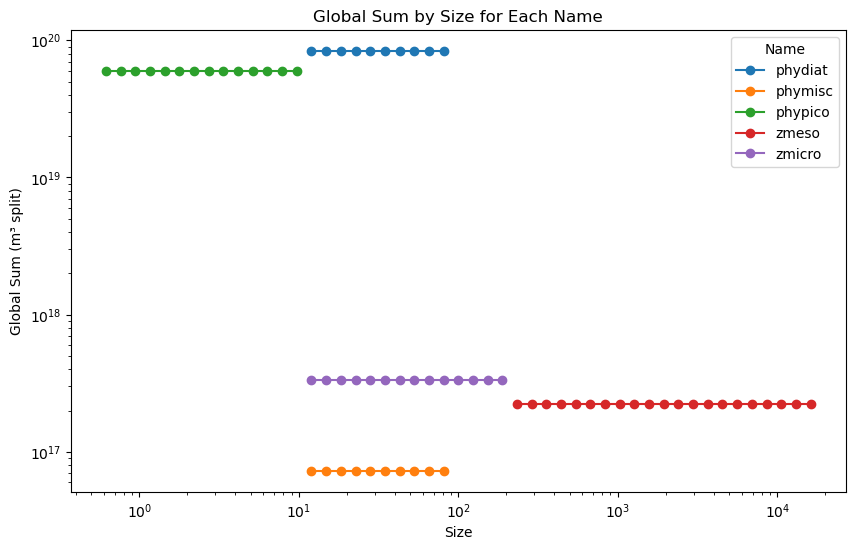

In [479]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming sdfm is your dataframe

plt.figure(figsize=(10, 6))

# Plot each group (by 'name') with lines and dots
# Add legend
for name, group in sdfm_GFDL.groupby('name'):
    plt.plot(group['sizes'], group['globalSum_m3_split'], marker='o', linestyle='-', label=name)

# Set log scale (common for size spectra)
plt.xscale('log')
plt.yscale('log')

# Labels and title
plt.xlabel('Size')
plt.ylabel('Global Sum (m³ split)')
plt.title('Global Sum by Size for Each Name')

# Add legend
plt.legend(title="Name")

plt.show()



## GISS

In [480]:
ds_hist = xr.open_mfdataset('/Users/mc4214/CMIP6_biome_PSS_data/biom_GISS_PSS_hist_biovolume.nc')

In [481]:
# dictionary with total biovolume
total_biovol_m3={}
total_biovol_m3['globalSum_m3']={}
total_biovol_m3['globalSum_m3']['phymisc'] = ds_hist.phymisc.mean(dim='time').sum(dim=['lon','lat']).values
total_biovol_m3['globalSum_m3']['phycalc'] = ds_hist.phycalc.mean(dim='time').sum(dim=['lon','lat']).values
total_biovol_m3['globalSum_m3']['phydiat'] = ds_hist.phydiat.mean(dim='time').sum(dim=['lon','lat']).values
total_biovol_m3['globalSum_m3']['zooc'] = ds_hist.zooc.mean(dim='time').sum(dim=['lon','lat']).values
# transform the dictionary to a dataframe
total_biovol_m3=pd.DataFrame.from_dict(total_biovol_m3)
total_biovol_m3=total_biovol_m3.reset_index()
total_biovol_m3.columns.values[0]='name'
total_biovol_m3

,name,globalSum_m3
0,phycalc,5.784107949191811e+21
1,phydiat,1.1896894828491006e+19
2,phymisc,2.1981319610966938e+19
3,zooc,2.520134982373648e+18


In [482]:
sizes=np.linspace(np.log10(2),np.log10(2.*1000.),num=50,endpoint=False)
#10**(sizes)
#sizes

In [483]:
dd=np.diff(sizes)[0]
sizes_min=10**(sizes-dd/2)
sizes_max=10**(sizes+dd/2)
size_range=[str(np.round(10**s,3))+': '+'['+str(np.round(x,3))+','+str(np.round(y,3))+')' for s,x,y in zip(sizes,sizes_min,sizes_max)]
#size_range

In [484]:
sizedf=pd.DataFrame([10**sizes]).transpose()
sizedf.columns=['sizes']
sizedf['phyto']= None
sizedf['phytomisc']= None # withoutphytomisc, phymisc information dissapears (it is all masked by phycalc)
sizedf['zoo']= None
#sizedf.loc[sizedf.sizes < 10,'phyto']='smp'
sizedf.loc[(sizedf.sizes > 2) & (sizedf.sizes < 10),'phytomisc']='phymisc'
sizedf.loc[(sizedf.sizes > 10) & (sizedf.sizes < 100),'phyto']='phydiat' ##Playing with diatom size 
sizedf.loc[(sizedf.sizes > 2) & (sizedf.sizes < 75),'phyto']='phycalc'
sizedf.loc[(sizedf.sizes > 10) & (sizedf.sizes < 2000),'zoo']='zooc'
#sizedf.loc[(sizedf.sizes > 2000) & (sizedf.sizes < 20000),'zoo']='lgz'
##this step is necessary to remove the empty categories when we are not considering phymisc


#sizedf

In [485]:
# determine the degree of overlap between size bins. In COBALT (and perhaps other models) the degree of overlap might need to be determined following 
# Jessica's method

# the goal is to have repeated entries for a size class if it occurs across plantkon types:
sdfm_GISS = pd.melt(sizedf, id_vars='sizes',var_name='type',value_name='name')
sdfm_GISS  = sdfm_GISS .dropna().reset_index(drop=True)
pd.set_option('display.max_rows',80)
sdfm_GISS ['biovolume_um3']=(4/3)*math.pi*(sdfm_GISS.sizes/2)**3

In [486]:
sdfm_GISS

,sizes,type,name,biovolume_um3
0,2.296307,phyto,phycalc,6.339991e+00
1,2.636513,phyto,phycalc,9.595964e+00
2,3.027122,phyto,phycalc,1.452408e+01
3,3.475602,phyto,phycalc,2.198308e+01
4,3.990525,phyto,phycalc,3.327274e+01
5,4.581735,phyto,phycalc,5.036033e+01
6,5.260536,phyto,phycalc,7.622345e+01
7,6.039903,phyto,phycalc,1.153689e+02
8,6.934737,phyto,phycalc,1.746178e+02
9,7.962143,phyto,phycalc,2.642948e+02


In [487]:

sdfm_GISS['globalSum_m3_split']=0
for s in sdfm_GISS.name.unique():
    n=len(sdfm_GISS.loc[sdfm_GISS.name==s].index)
    print(s, n)
    sdfm_GISS.loc[sdfm_GISS.name==s,'globalSum_m3_split'] = np.tile(total_biovol_m3.loc[total_biovol_m3.name==s,'globalSum_m3']/n,n)
#sdfm_CESM

phycalc 26
phydiat 2
phymisc 11
zooc 38


In [488]:
sdfm_GISS= sdfm_GISS.sort_values(by='biovolume_um3', ascending=True)

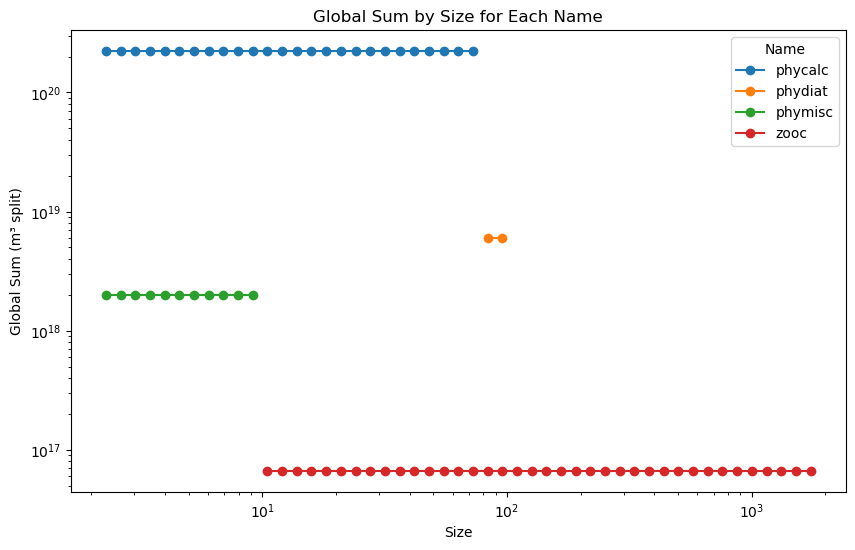

In [489]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming sdfm is your dataframe

plt.figure(figsize=(10, 6))

# Plot each group (by 'name') with lines and dots
# Add legend
for name, group in sdfm_GISS.groupby('name'):
    plt.plot(group['sizes'], group['globalSum_m3_split'], marker='o', linestyle='-', label=name)

# Set log scale (common for size spectra)
plt.xscale('log')
plt.yscale('log')

# Labels and title
plt.xlabel('Size')
plt.ylabel('Global Sum (m³ split)')
plt.title('Global Sum by Size for Each Name')

# Add legend
plt.legend(title="Name")

plt.show()



## IPSL

In [490]:
ds_hist = xr.open_mfdataset('/Users/mc4214/CMIP6_biome_PSS_data/biom_IPSL_PSS_hist_biovolume.nc')

In [491]:
# dictionary with total biovolume
total_biovol_m3={}
total_biovol_m3['globalSum_m3']={}
total_biovol_m3['globalSum_m3']['phydiat'] = ds_hist.phydiat.mean(dim='time').sum(dim=['lon','lat']).values
total_biovol_m3['globalSum_m3']['phymisc'] = ds_hist.phymisc.mean(dim='time').sum(dim=['lon','lat']).values
total_biovol_m3['globalSum_m3']['zmicro'] = ds_hist.zmicro.mean(dim='time').sum(dim=['lon','lat']).values
total_biovol_m3['globalSum_m3']['zmeso'] = ds_hist.zmicro.mean(dim='time').sum(dim=['lon','lat']).values
# transform the dictionary to a dataframe
total_biovol_m3=pd.DataFrame.from_dict(total_biovol_m3)
total_biovol_m3=total_biovol_m3.reset_index()
total_biovol_m3.columns.values[0]='name'
total_biovol_m3

,name,globalSum_m3
0,phydiat,7.767925457791656e+20
1,phymisc,2.0267903314157183e+19
2,zmeso,3.3724491858451245e+17
3,zmicro,3.3724491858451245e+17


In [492]:
sizes=np.linspace(np.log10(1),np.log10(2.*1000.),num=50,endpoint=False)
#10**(sizes)
#sizes

In [493]:
dd=np.diff(sizes)[0]
sizes_min=10**(sizes-dd/2)
sizes_max=10**(sizes+dd/2)
size_range=[str(np.round(10**s,3))+': '+'['+str(np.round(x,3))+','+str(np.round(y,3))+')' for s,x,y in zip(sizes,sizes_min,sizes_max)]
#size_range

In [494]:
sizedf=pd.DataFrame([10**sizes]).transpose()
sizedf.columns=['sizes']
sizedf['phyto']= None
sizedf['zoo']= None
#sizedf.loc[sizedf.sizes < 10,'phyto']='smp'
sizedf.loc[(sizedf.sizes >1) & (sizedf.sizes < 10),'phyto']='phymisc'
sizedf.loc[(sizedf.sizes > 10) & (sizedf.sizes < 40),'phyto']='phydiat' ##Playing with diatom size 
sizedf.loc[(sizedf.sizes > 10) & (sizedf.sizes < 200),'zoo']='zmicro'
sizedf.loc[(sizedf.sizes > 200) & (sizedf.sizes < 2000),'zoo']='zmeso'
#sizedf.loc[(sizedf.sizes > 2000) & (sizedf.sizes < 20000),'zoo']='lgz'
##this step is necessary to remove the empty categories when we are not considering phymisc



sizedf = sizedf.reset_index(drop=True)


In [495]:
# determine the degree of overlap between size bins. In COBALT (and perhaps other models) the degree of overlap might need to be determined following 
# Jessica's method

# the goal is to have repeated entries for a size class if it occurs across plantkon types:
sdfm_IPSL = pd.melt(sizedf, id_vars='sizes',var_name='type',value_name='name')
sdfm_IPSL  = sdfm_IPSL .dropna().reset_index(drop=True)
pd.set_option('display.max_rows',80)
sdfm_IPSL['biovolume_um3']=(4/3)*math.pi*(sdfm_IPSL.sizes/2)**3

In [496]:
sdfm_IPSL

,sizes,type,name,biovolume_um3
0,1.164181,phyto,phymisc,8.261529e-01
1,1.355318,phyto,phymisc,1.303534e+00
2,1.577836,phyto,phymisc,2.056762e+00
3,1.836887,phyto,phymisc,3.245233e+00
4,2.138469,phyto,phymisc,5.120444e+00
5,2.489566,phyto,phymisc,8.079220e+00
6,2.898306,phyto,phymisc,1.274768e+01
7,3.374153,phyto,phymisc,2.011375e+01
8,3.928126,phyto,phymisc,3.173619e+01
9,4.573051,phyto,phymisc,5.007450e+01


In [497]:

sdfm_IPSL['globalSum_m3_split']=0
for s in sdfm_IPSL.name.unique():
    n=len(sdfm_IPSL.loc[sdfm_IPSL.name==s].index)
    print(s, n)
    sdfm_IPSL.loc[sdfm_IPSL.name==s,'globalSum_m3_split'] = np.tile(total_biovol_m3.loc[total_biovol_m3.name==s,'globalSum_m3']/n,n)
#sdfm_CESM

phymisc 15
phydiat 9
zmicro 19
zmeso 15


In [498]:
sdfm_IPSL= sdfm_IPSL.sort_values(by='biovolume_um3', ascending=True)

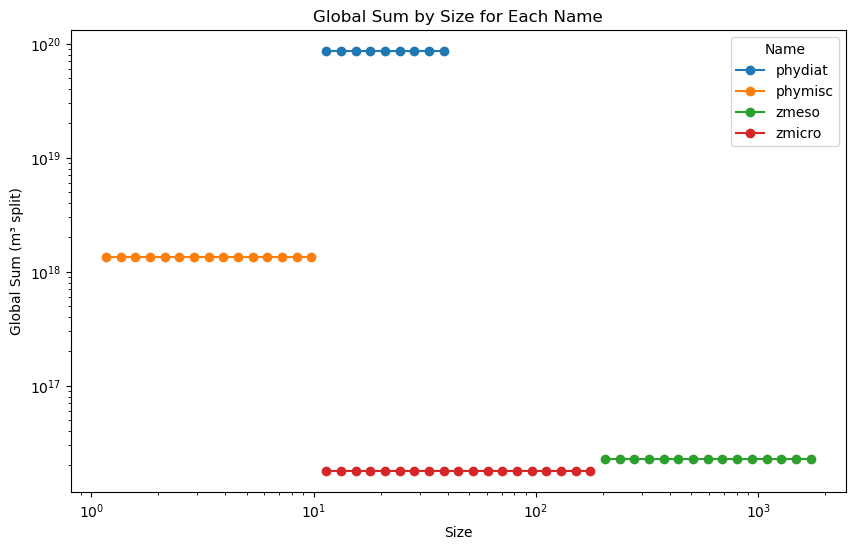

In [499]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming sdfm is your dataframe

plt.figure(figsize=(10, 6))

# Plot each group (by 'name') with lines and dots
# Add legend
for name, group in sdfm_IPSL.groupby('name'):
    plt.plot(group['sizes'], group['globalSum_m3_split'], marker='o', linestyle='-', label=name)

# Set log scale (common for size spectra)
plt.xscale('log')
plt.yscale('log')

# Labels and title
plt.xlabel('Size')
plt.ylabel('Global Sum (m³ split)')
plt.title('Global Sum by Size for Each Name')

# Add legend
plt.legend(title="Name")

plt.show()



## UKESM

In [500]:
ds_hist = xr.open_mfdataset('/Users/mc4214/CMIP6_biome_PSS_data/biom_UKESM_PSS_hist_biovolume.nc')

In [501]:
ds_hist


<xarray.Dataset>
Dimensions:               (lat: 180, lon: 360, time: 360, biovol_um3: 50)
Coordinates:
  * time                  (time) datetime64[ns] 1985-01-16 ... 2014-12-16
  * lat                   (lat) float64 -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
  * lon                   (lon) float64 -179.5 -178.5 -177.5 ... 178.5 179.5
  * biovol_um3            (biovol_um3) float64 5.316 8.041 ... 3.408e+09
Data variables: (12/19)
    biomes                (lat, lon, time) float64 dask.array<chunksize=(180, 360, 360), meta=np.ndarray>
    chl                   (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    NB                    (biovol_um3, time, lat, lon) float64 dask.array<chunksize=(50, 360, 180, 360), meta=np.ndarray>
    total_biovolume_hist  (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    betas_hist            (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    intercept_hist        (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    ...                    ...
    phymisc_per           (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    phydiat_per           (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    zmicro_per            (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    zmeso_per             (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    phyc                  (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    zooc                  (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>

In [502]:
# dictionary with total biovolume
total_biovol_m3={}
total_biovol_m3['globalSum_m3']={}
total_biovol_m3['globalSum_m3']['phydiat'] = ds_hist.phydiat.mean(dim='time').sum(dim=['lon','lat']).values
total_biovol_m3['globalSum_m3']['phymisc'] = ds_hist.phymisc.mean(dim='time').sum(dim=['lon','lat']).values
total_biovol_m3['globalSum_m3']['zmicro'] = ds_hist.zmicro.mean(dim='time').sum(dim=['lon','lat']).values
total_biovol_m3['globalSum_m3']['zmeso'] = ds_hist.zmicro.mean(dim='time').sum(dim=['lon','lat']).values
# transform the dictionary to a dataframe
total_biovol_m3=pd.DataFrame.from_dict(total_biovol_m3)
total_biovol_m3=total_biovol_m3.reset_index()
total_biovol_m3.columns.values[0]='name'
total_biovol_m3

,name,globalSum_m3
0,phydiat,1.2319708688198975e+19
1,phymisc,1.6214124470594886e+19
2,zmeso,4.8454165133359066e+17
3,zmicro,4.8454165133359066e+17


In [503]:
sizes=np.linspace(np.log10(2),np.log10(2.*1000.),num=50,endpoint=False)
#10**(sizes)
#sizes

In [504]:
dd=np.diff(sizes)[0]
sizes_min=10**(sizes-dd/2)
sizes_max=10**(sizes+dd/2)
size_range=[str(np.round(10**s,3))+': '+'['+str(np.round(x,3))+','+str(np.round(y,3))+')' for s,x,y in zip(sizes,sizes_min,sizes_max)]
#size_range

In [505]:
sizedf=pd.DataFrame([10**sizes]).transpose()
sizedf.columns=['sizes']
sizedf['phyto']= None
sizedf['zoo']= None
#sizedf.loc[sizedf.sizes < 10,'phyto']='smp'
sizedf.loc[(sizedf.sizes > 2) & (sizedf.sizes < 20),'phyto']='phymisc'
sizedf.loc[(sizedf.sizes > 20) & (sizedf.sizes < 100),'phyto']='phydiat' 
sizedf.loc[(sizedf.sizes > 10) & (sizedf.sizes < 200),'zoo']='zmicro'
sizedf.loc[(sizedf.sizes > 200) & (sizedf.sizes < 2000),'zoo']='zmeso'
#sizedf.loc[(sizedf.sizes > 2000) & (sizedf.sizes < 20000),'zoo']='lgz'
##this step is necessary to remove the empty categories when we are not considering phymisc



sizedf = sizedf.reset_index(drop=True)

#sizedf

In [506]:
# determine the degree of overlap between size bins. In COBALT (and perhaps other models) the degree of overlap might need to be determined following 
# Jessica's method

# the goal is to have repeated entries for a size class if it occurs across plantkon types:
sdfm_UKESM = pd.melt(sizedf, id_vars='sizes',var_name='type',value_name='name')
sdfm_UKESM  = sdfm_UKESM .dropna().reset_index(drop=True)
pd.set_option('display.max_rows',80)
sdfm_UKESM['biovolume_um3']=(4/3)*math.pi*(sdfm_UKESM.sizes/2)**3

In [507]:

sdfm_UKESM['globalSum_m3_split']=0
for s in sdfm_UKESM.name.unique():
    n=len(sdfm_UKESM.loc[sdfm_UKESM.name==s].index)
    print(s, n)
    sdfm_UKESM.loc[sdfm_UKESM.name==s,'globalSum_m3_split'] = np.tile(total_biovol_m3.loc[total_biovol_m3.name==s,'globalSum_m3']/n,n)
#sdfm_CESM

phymisc 16
phydiat 12
zmicro 22
zmeso 16


In [508]:
sdfm_UKESM


,sizes,type,name,biovolume_um3,globalSum_m3_split
0,2.296307,phyto,phymisc,6.339991e+00,1013382779412180352.0
1,2.636513,phyto,phymisc,9.595964e+00,1013382779412180352.0
2,3.027122,phyto,phymisc,1.452408e+01,1013382779412180352.0
3,3.475602,phyto,phymisc,2.198308e+01,1013382779412180352.0
4,3.990525,phyto,phymisc,3.327274e+01,1013382779412180352.0
5,4.581735,phyto,phymisc,5.036033e+01,1013382779412180352.0
6,5.260536,phyto,phymisc,7.622345e+01,1013382779412180352.0
7,6.039903,phyto,phymisc,1.153689e+02,1013382779412180352.0
8,6.934737,phyto,phymisc,1.746178e+02,1013382779412180352.0
9,7.962143,phyto,phymisc,2.642948e+02,1013382779412180352.0


In [509]:
sdfm_UKESM= sdfm_UKESM.sort_values(by='biovolume_um3', ascending=True)

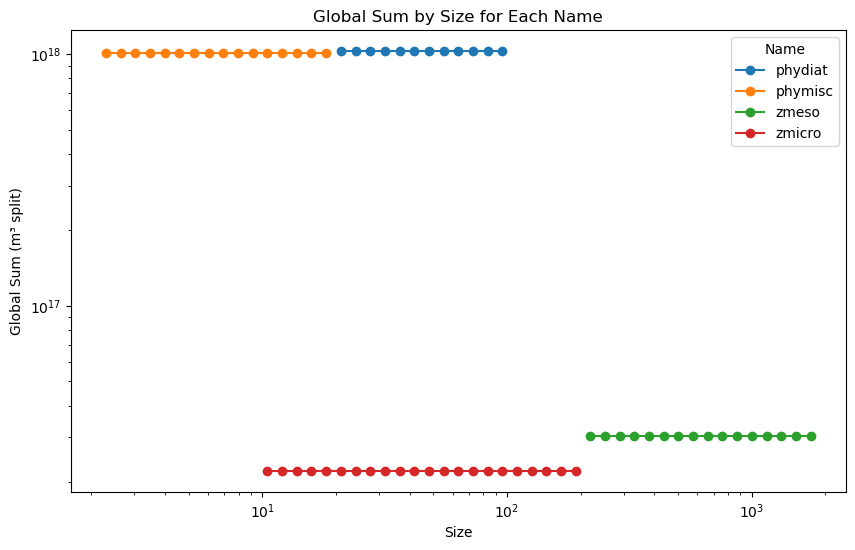

In [510]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming sdfm is your dataframe

plt.figure(figsize=(10, 6))

# Plot each group (by 'name') with lines and dots
# Add legend
for name, group in sdfm_UKESM.groupby('name'):
    plt.plot(group['sizes'], group['globalSum_m3_split'], marker='o', linestyle='-', label=name)

# Set log scale (common for size spectra)
plt.xscale('log')
plt.yscale('log')

# Labels and title
plt.xlabel('Size')
plt.ylabel('Global Sum (m³ split)')
plt.title('Global Sum by Size for Each Name')

# Add legend
plt.legend(title="Name")

plt.show()



## FIGURES FOR SUPPLEMENTARY MATERIAL

In [511]:
## setting up dictionary of model and PFTs
  
# Creating an empty dictionary
PSS_dict = {}

 
# Adding list as value

PSS_dict['CESM'] = sdfm_CESM
PSS_dict['CMCC'] = sdfm_CMCC
PSS_dict['CNRM'] = sdfm_CNRM
PSS_dict['GFDL']= sdfm_GFDL
PSS_dict['GISS'] = sdfm_GISS
PSS_dict['IPSL'] = sdfm_IPSL
PSS_dict['UKESM'] = sdfm_UKESM

In [512]:
for key in PSS_dict:
    PSS_dict[key]['sizes'] = pd.to_numeric(PSS_dict[key]['sizes'], errors='coerce')
    PSS_dict[key]['globalSum_m3_split'] = pd.to_numeric(PSS_dict[key]['globalSum_m3_split'], errors='coerce')

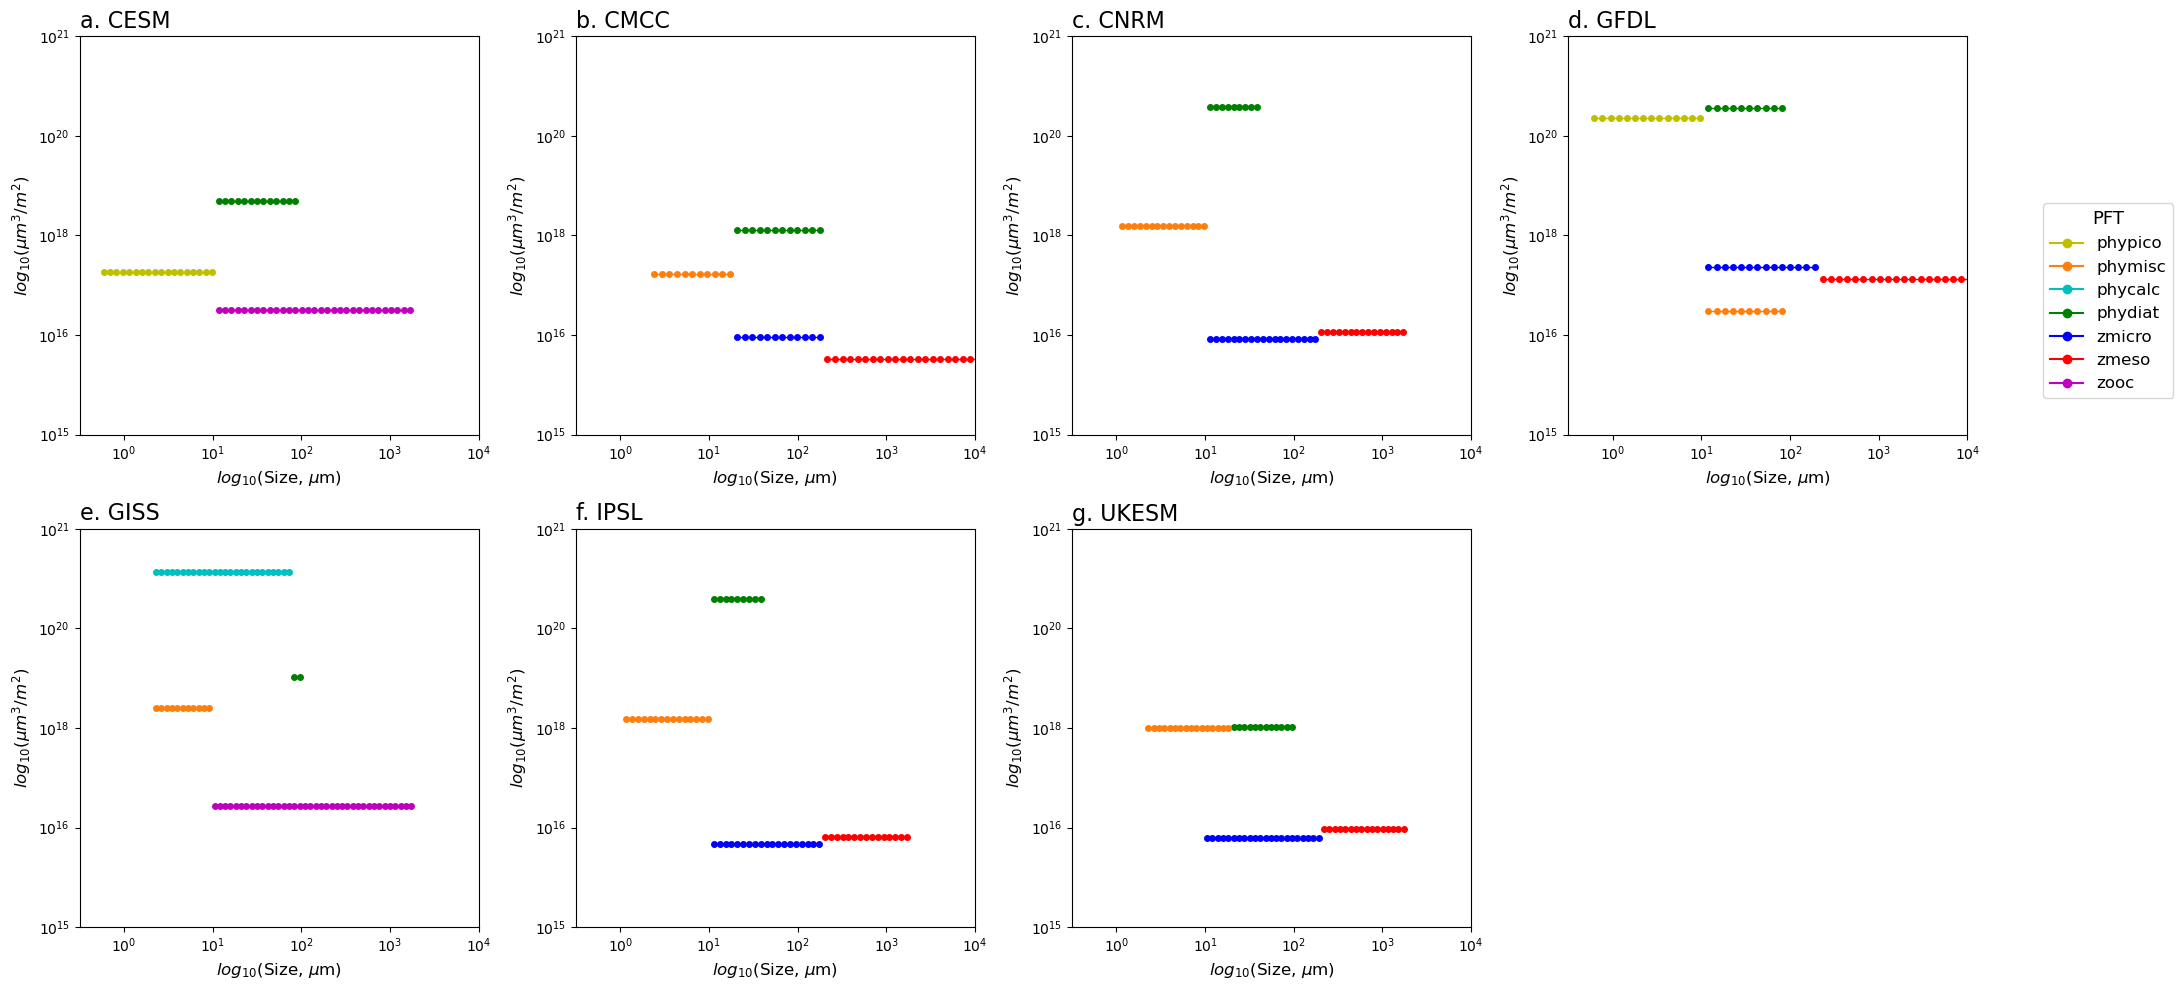

In [513]:
import matplotlib.gridspec as gridspec
from matplotlib.ticker import LogLocator, ScalarFormatter
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker


# Palette and letters
palette_pft = {
    'phypico': 'y',
    'phymisc': '#ff7f0e',
    'phycalc': 'c',
    'phydiat': 'g',
    'zmicro': 'b',
    'zmeso': 'r',
    'zooc': 'm'
}
letters = ['a.', 'b.', 'c.', 'd.', 'e.', 'f.', 'g.']

# Create figure and 2x4 grid
fig = plt.figure(figsize=(20, 10))
gs = gridspec.GridSpec(2, 4, figure=fig)

# First row: 4 panels, second row: 3 panels aligned left
axes = [fig.add_subplot(gs[0, i]) for i in range(4)]
axes += [fig.add_subplot(gs[1, i]) for i in range(3)]

# Collect global min/max for consistent limits
x_min, x_max = np.inf, -np.inf
y_min, y_max = np.inf, -np.inf
for df in PSS_dict.values():
    sizes_log = np.log10(pd.to_numeric(df['sizes'], errors='coerce'))
    global_log = np.log10(pd.to_numeric(df['globalSum_m3_split'], errors='coerce'))
    x_min, x_max = min(x_min, sizes_log.min()), max(x_max, sizes_log.max())
    y_min, y_max = min(y_min, global_log.min()), max(y_max, global_log.max())

# Plotting loop
for idx, (model, df) in enumerate(PSS_dict.items()):
    ax = axes[idx]

    df['sizes'] = pd.to_numeric(df['sizes'], errors='coerce')
    df['globalSum_m3_split'] = pd.to_numeric(df['globalSum_m3_split'], errors='coerce')

    for name, group in df.groupby('name'):
        ax.plot(
            np.log10(group['sizes'].values),
            np.log10(group['globalSum_m3_split'].values),
            #group['globalSum_m3_split'].values,
            marker='o', linestyle='-',
            markersize=4, linewidth=1,
            color=palette_pft.get(name, 'k')
        )

    # Panel letter and title
    ax.set_title(f"{letters[idx]} {model}", loc='left', fontsize=16)

    # Axis labels
    ax.set_xlabel(r'$log_{10}$(Size, $\mu$m)', fontsize=12)
    ax.set_ylabel(r'$log_{10}(\mu m^3/m^2)$', fontsize=12)

    # Apply consistent limits
    ax.set_xlim(-0.5, 4)
    ax.set_ylim(15, 21)

    # Force tick format as 10^x
    ax.xaxis.set_major_locator(mticker.MaxNLocator(5))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
    ax.xaxis.set_major_formatter(mticker.StrMethodFormatter(r"$10^{{{x:.0f}}}$"))
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter(r"$10^{{{x:.0f}}}$"))

    ax.tick_params(axis='both', which='major', labelsize=10)

# Global legend outside (right side)
handles = [plt.Line2D([0], [0], color=col, marker='o', linestyle='-', markersize=6)
           for col in palette_pft.values()]
labels = list(palette_pft.keys())
fig.legend(handles, labels, title="PFT", bbox_to_anchor=(1.02, 0.8),
           loc='upper left', fontsize=12, title_fontsize=13)

output_path = '/Users/mc4214/GIT/CMIP6_size_spectra/figures/fig_supp_Sheldon_dist_biovol.png'

plt.tight_layout()
fig.savefig(output_path, dpi=300, bbox_inches='tight')  # This preserves legend
plt.show()  